In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import duckdb 
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flight-price-prediction/business.csv
/kaggle/input/flight-price-prediction/economy.csv
/kaggle/input/flight-price-prediction/Clean_Dataset.csv


# EDA using pandas

In [2]:
Clean_Dataset_df = pd.read_csv("/kaggle/input/flight-price-prediction/Clean_Dataset.csv")
Clean_Dataset_df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
Clean_Dataset_df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [4]:
Clean_Dataset_df.drop('Unnamed: 0',axis=1,inplace=True)

In [5]:
Clean_Dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [6]:
Clean_Dataset_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
airline,300153,6,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight,300153,1561,UK-706,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_city,300153,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_time,300153,6,Morning,71146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stops,300153,3,one,250863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,300153,6,Night,91538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,300153,6,Mumbai,59097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,300153,2,Economy,206666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,300153.0,NaN,NaN,NaN,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,NaN,NaN,NaN,26.004751,13.561004,1.0,15.0,26.0,38.0,49.0


In [7]:
Clean_Dataset_df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


## Discovery #1: Airline
`Vistara`, `Indigo` and `Air_India` are the airlines with top 3 flight frequency. 


In [8]:
Clean_Dataset_df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [9]:
Clean_Dataset_df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

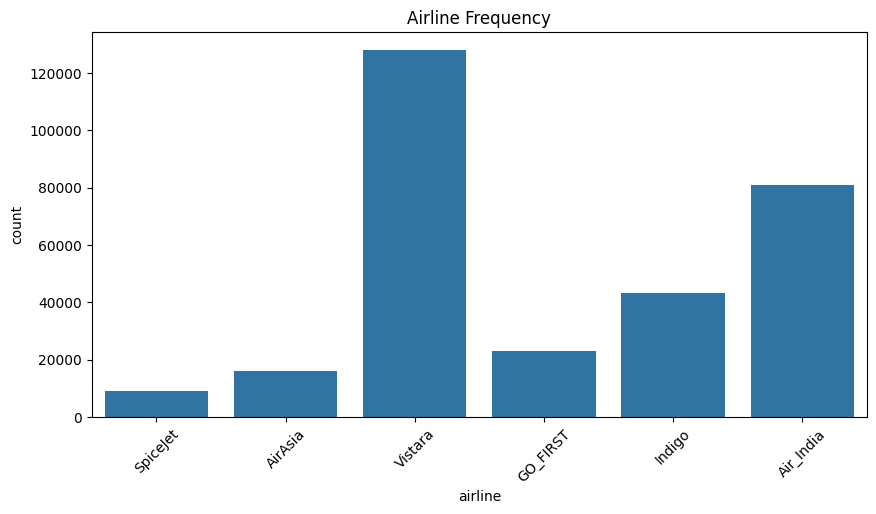

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(data=Clean_Dataset_df, x="airline")
plt.xticks(rotation=45)
plt.title("Airline Frequency")
plt.show()

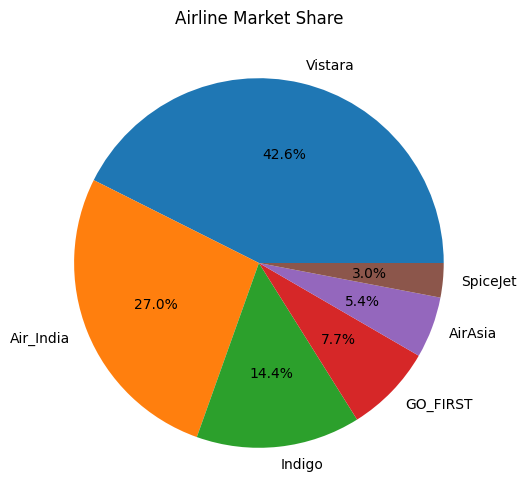

In [11]:
Clean_Dataset_df["airline"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Airline Market Share")
plt.ylabel("")
plt.show()

## Discovery #2: Source City
`Delhi` and `Mumbai` is showing similar frequency (Top 1 and Top 2) of Source City, followed by `Bangalore` as the Top 3 source city in this dataset.

In [12]:
 Clean_Dataset_df['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

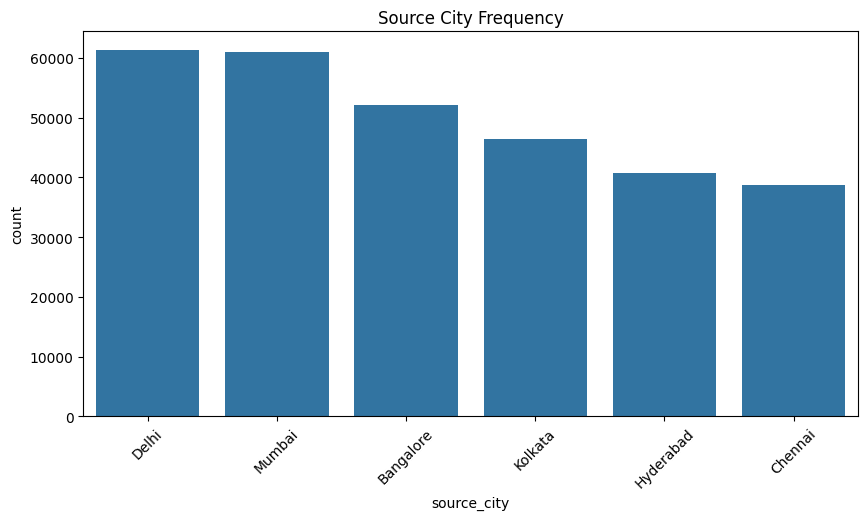

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(data=Clean_Dataset_df, x="source_city")
plt.xticks(rotation=45)
plt.title("Source City Frequency")
plt.show()

## Discovery #3: Departure Time
Most customers prefer to depart to their destination during `Morning` and `Early Morning` session, followed by `Evening` timeslot.

In [14]:
 Clean_Dataset_df['departure_time'].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

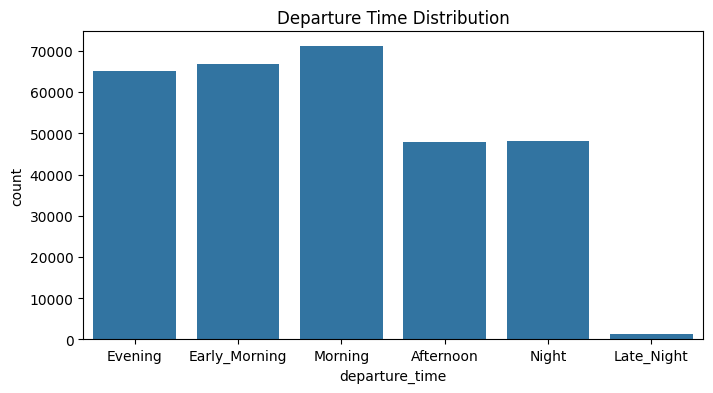

In [15]:
plt.figure(figsize=(8,4))
sns.countplot(data=Clean_Dataset_df, x="departure_time")
plt.title("Departure Time Distribution")
plt.show()

## Discovery #4: Stops
Most flights has at least 1 stop.

In [16]:
 Clean_Dataset_df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [17]:
 Clean_Dataset_df['stops'].value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

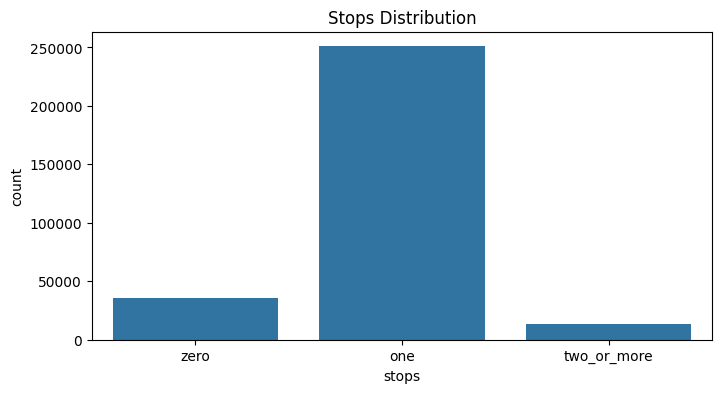

In [18]:
plt.figure(figsize=(8,4))
sns.countplot(data=Clean_Dataset_df, x="stops")
plt.title("Stops Distribution")
plt.show()

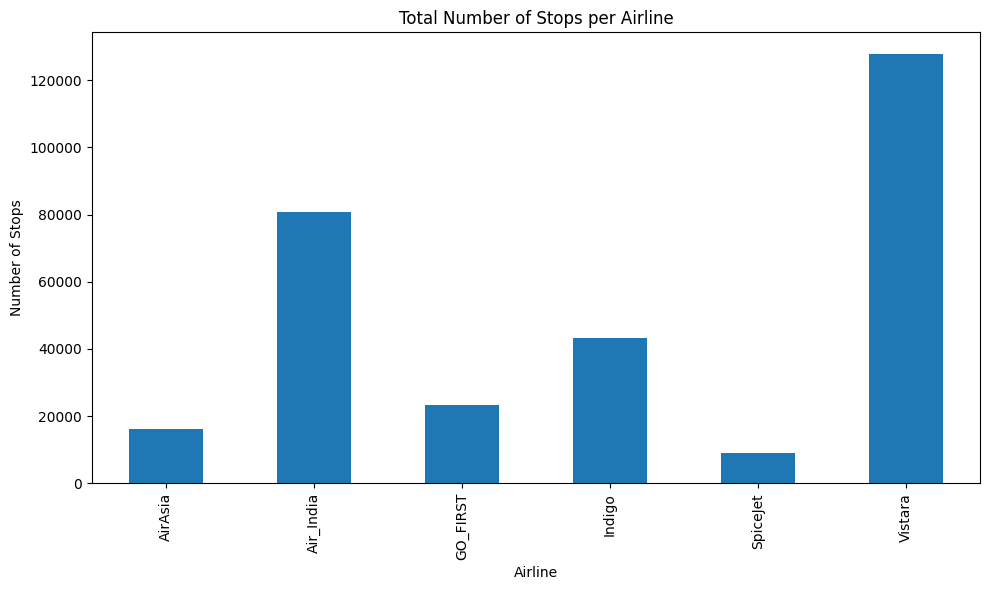

In [19]:
import matplotlib.pyplot as plt
airline_price = Clean_Dataset_df.groupby('airline')['stops'].count()

plt.figure(figsize=(10, 6))
airline_price.plot(kind='bar')
plt.xlabel('Airline')
plt.ylabel('Number of Stops')
plt.title('Total Number of Stops per Airline')
plt.tight_layout()
plt.show()

## Discovery #5: Arrival Time
Most customers arrive at their destination during `Night` session, followed by `Evening` session and `Morning` session.

In [20]:
Clean_Dataset_df['arrival_time'].unique()

array(['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening',
       'Late_Night'], dtype=object)

In [21]:
Clean_Dataset_df['arrival_time'].value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

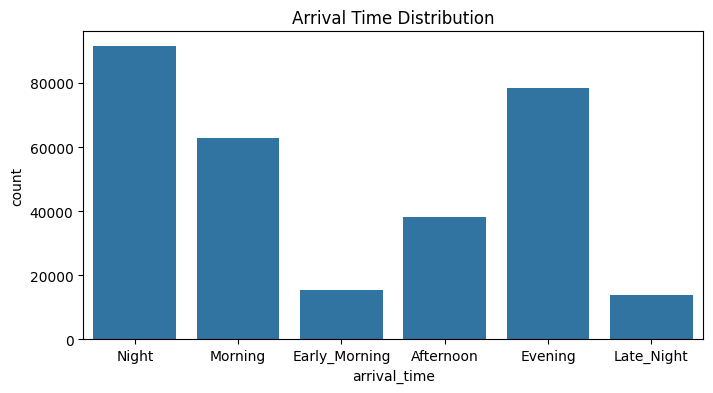

In [22]:
plt.figure(figsize=(8,4))
sns.countplot(data=Clean_Dataset_df, x="arrival_time")
plt.title("Arrival Time Distribution")
plt.show()

## Discovery #6: Destination City
`Delhi` and `Mumbai` is showing similar frequency (Top 1 and Top 2) of Destination City, followed by `Bangalore` as the Top 3 source city in this dataset.

In [23]:
 Clean_Dataset_df['destination_city'].value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

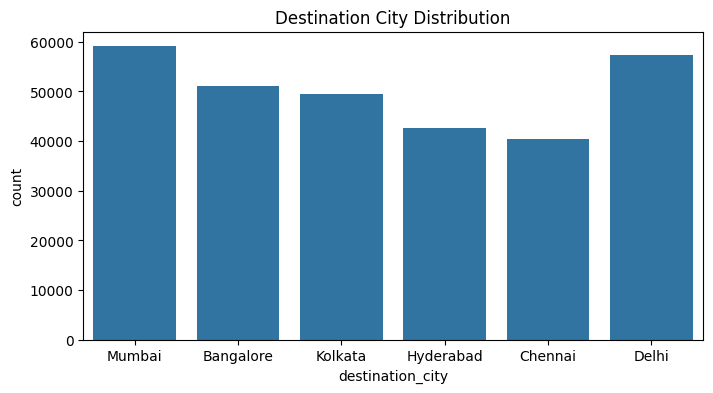

In [24]:
plt.figure(figsize=(8,4))
sns.countplot(data=Clean_Dataset_df, x="destination_city")
plt.title("Destination City Distribution")
plt.show()

## Discovery #7: Class
There are two classes of flight services available in this dataset. 

In [25]:
Clean_Dataset_df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

## Discovery #8: duration, days_left, price

In [26]:
# Correlation
corr = Clean_Dataset_df['duration'].corr(Clean_Dataset_df['price'])
print(f"Correlation Coefficient: {corr:.3f}")

Correlation Coefficient: 0.204


In [27]:
# Correlation
corr = Clean_Dataset_df['days_left'].corr(Clean_Dataset_df['price'])
print(f"Correlation Coefficient: {corr:.3f}")

Correlation Coefficient: -0.092


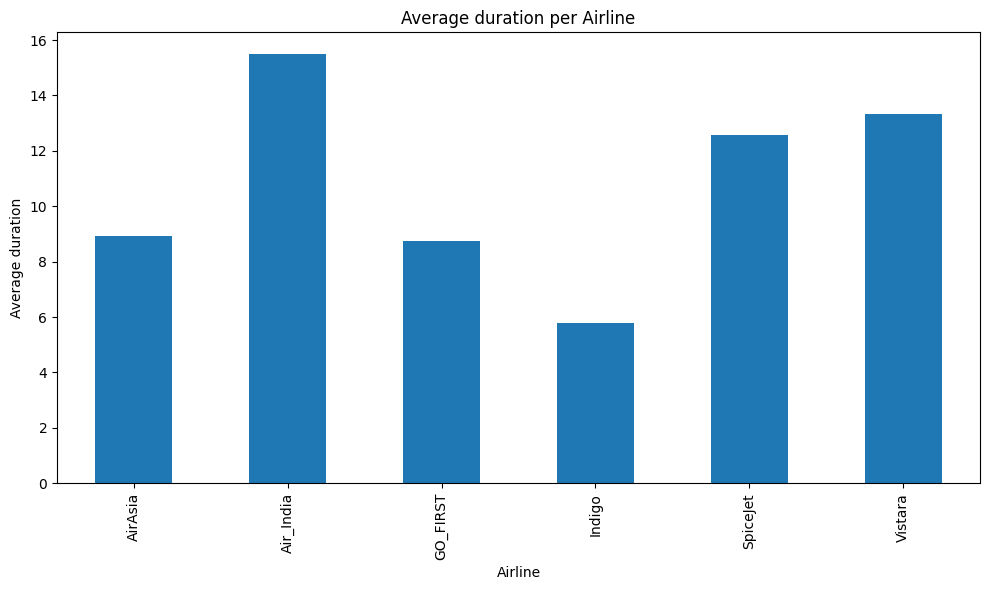

In [28]:
import matplotlib.pyplot as plt
airline_price = Clean_Dataset_df.groupby('airline')['duration'].mean()

plt.figure(figsize=(10, 6))
airline_price.plot(kind='bar')
plt.xlabel('Airline')
plt.ylabel('Average duration')
plt.title('Average duration per Airline')
plt.tight_layout()
plt.show()

# EDA (Exploratory Data Analysis) using DuckDB

In [29]:
conn = duckdb.connect(database=':memory:', read_only=False)

No permanent table created in DuckDB, memory is used for EDA instead. 

In [30]:
conn.sql('show tables')

┌─────────┐
│  name   │
│ varchar │
├─────────┤
│ 0 rows  │
└─────────┘

In [31]:
duckdb.sql("""
CREATE TABLE test AS SELECT * FROM Clean_Dataset_df
""")

In [32]:
duckdb.sql("""
SELECT * FROM test;
""").show()

┌───────────┬─────────┬─────────────┬────────────────┬─────────┬───────────────┬──────────────────┬─────────┬──────────┬───────────┬───────┐
│  airline  │ flight  │ source_city │ departure_time │  stops  │ arrival_time  │ destination_city │  class  │ duration │ days_left │ price │
│  varchar  │ varchar │   varchar   │    varchar     │ varchar │    varchar    │     varchar      │ varchar │  double  │   int64   │ int64 │
├───────────┼─────────┼─────────────┼────────────────┼─────────┼───────────────┼──────────────────┼─────────┼──────────┼───────────┼───────┤
│ SpiceJet  │ SG-8709 │ Delhi       │ Evening        │ zero    │ Night         │ Mumbai           │ Economy │     2.17 │         1 │  5953 │
│ SpiceJet  │ SG-8157 │ Delhi       │ Early_Morning  │ zero    │ Morning       │ Mumbai           │ Economy │     2.33 │         1 │  5953 │
│ AirAsia   │ I5-764  │ Delhi       │ Early_Morning  │ zero    │ Early_Morning │ Mumbai           │ Economy │     2.17 │         1 │  5956 │
│ Vistara   │

## Discovery #9: PIVOT - Stops
- The average flight duration of airlines tends to increase as number of stops increases
- The average flight duration for path with `zero` stops ranges from 2.075 to 2.33 hours
- As number of stop increases, travel time increases at least by 3 times. 
- `SpiceJet` doesn't offer flight services that comes with `two_or_more` number of stops

In [33]:
duckdb.sql("""
PIVOT test
ON stops
USING avg(duration)
GROUP BY airline
ORDER BY airline DESC;
""")

┌───────────┬────────────────────┬────────────────────┬────────────────────┐
│  airline  │        one         │    two_or_more     │        zero        │
│  varchar  │       double       │       double       │       double       │
├───────────┼────────────────────┼────────────────────┼────────────────────┤
│ Vistara   │  14.27023781041729 │ 14.706963228420038 │ 2.2379688109161733 │
│ SpiceJet  │ 16.432873721178698 │               NULL │ 2.3303777416734412 │
│ Indigo    │  7.033981903356207 │  9.868807588075903 │  2.084934022824534 │
│ GO_FIRST  │  9.790916346891787 │ 11.444197530864201 │ 2.1377784672665214 │
│ Air_India │  16.43799025407018 │  20.73369071572289 │  2.320647526915277 │
│ AirAsia   │    9.9693729199509 │ 11.159238646482644 │  2.074679539852107 │
└───────────┴────────────────────┴────────────────────┴────────────────────┘

## Discovery #10: PIVOT - Class

- Only `Vistara` and `Air_India` offers business class travel package to their customers.
- In general, lesser travel time is required for `Business` class to complete their flight services.

In [34]:
duckdb.sql("""
PIVOT test
ON class
USING avg(duration)
GROUP BY airline
ORDER BY airline DESC;
""")

┌───────────┬────────────────────┬────────────────────┐
│  airline  │      Business      │      Economy       │
│  varchar  │       double       │       double       │
├───────────┼────────────────────┼────────────────────┤
│ Vistara   │ 13.198962682995077 │ 13.441626430801495 │
│ SpiceJet  │               NULL │ 12.579766951503611 │
│ Indigo    │               NULL │  5.795196660482378 │
│ GO_FIRST  │               NULL │  8.755379968066334 │
│ Air_India │ 14.634917016232084 │  16.10011876484558 │
│ AirAsia   │               NULL │  8.941714498695383 │
└───────────┴────────────────────┴────────────────────┘

In [35]:
duckdb.sql("""
SELECT airline, COUNT(class) AS Number_of_Flights, AVG(duration) AS avg_duration
FROM test 
WHERE class = 'Business'
GROUP BY airline;
""").show()

┌───────────┬───────────────────┬────────────────────┐
│  airline  │ Number_of_Flights │    avg_duration    │
│  varchar  │       int64       │       double       │
├───────────┼───────────────────┼────────────────────┤
│ Vistara   │             60589 │ 13.198962682995077 │
│ Air_India │             32898 │ 14.634917016232084 │
└───────────┴───────────────────┴────────────────────┘



## Discovery #11: PIVOT - Source City to Destination City
Unlike other airplane service providers, `SpiceJet` airline is yet to offer flight travel services between some part of India. <br>
Example: Mumbai_to_Hyderabad, Hyderabad_to_Bangalore, and Hyderabad_to_Mumbai 

In [36]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Mumbai')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬─────────────────────┬───────────────────┬─────────────────┬─────────────────────┬───────────────────┐
│  airline  │ Mumbai_to_Bangalore │ Mumbai_to_Chennai │ Mumbai_to_Delhi │ Mumbai_to_Hyderabad │ Mumbai_to_Kolkata │
│  varchar  │       double        │      double       │     double      │       double        │      double       │
├───────────┼─────────────────────┼───────────────────┼─────────────────┼─────────────────────┼───────────────────┤
│ Vistara   │              11.692 │            13.743 │           9.773 │              13.214 │            13.267 │
│ SpiceJet  │               14.94 │             5.047 │           6.601 │                NULL │            16.831 │
│ Indigo    │               5.175 │             5.365 │            4.39 │               3.716 │             5.881 │
│ GO_FIRST  │               8.501 │             4.247 │           6.312 │               10.23 │             9.998 │
│ Air_India │              16.196 │            16.199 │          13.274 

In [37]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Delhi')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬────────────────────┬──────────────────┬────────────────────┬──────────────────┬─────────────────┐
│  airline  │ Delhi_to_Bangalore │ Delhi_to_Chennai │ Delhi_to_Hyderabad │ Delhi_to_Kolkata │ Delhi_to_Mumbai │
│  varchar  │       double       │      double      │       double       │      double      │     double      │
├───────────┼────────────────────┼──────────────────┼────────────────────┼──────────────────┼─────────────────┤
│ Vistara   │             10.131 │           12.556 │             13.397 │           14.766 │          10.323 │
│ SpiceJet  │             13.066 │           15.147 │              5.404 │            11.88 │           8.172 │
│ Indigo    │              6.572 │            6.672 │              5.593 │            5.124 │           5.005 │
│ GO_FIRST  │               7.17 │            9.442 │              7.695 │           10.378 │           6.598 │
│ Air_India │             15.081 │           16.745 │             15.826 │           16.171 │          1

In [38]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Bangalore')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬──────────────────────┬────────────────────┬────────────────────────┬──────────────────────┬─────────────────────┐
│  airline  │ Bangalore_to_Chennai │ Bangalore_to_Delhi │ Bangalore_to_Hyderabad │ Bangalore_to_Kolkata │ Bangalore_to_Mumbai │
│  varchar  │        double        │       double       │         double         │        double        │       double        │
├───────────┼──────────────────────┼────────────────────┼────────────────────────┼──────────────────────┼─────────────────────┤
│ Vistara   │               15.437 │             10.177 │                 16.281 │               15.493 │              11.016 │
│ SpiceJet  │                 1.08 │             13.185 │                  1.046 │                8.894 │              13.221 │
│ Indigo    │                1.039 │              6.099 │                  5.011 │                 6.89 │               5.111 │
│ GO_FIRST  │               10.518 │               7.48 │                  9.377 │               10.552 

In [39]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Chennai')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬──────────────────────┬──────────────────┬──────────────────────┬────────────────────┬───────────────────┐
│  airline  │ Chennai_to_Bangalore │ Chennai_to_Delhi │ Chennai_to_Hyderabad │ Chennai_to_Kolkata │ Chennai_to_Mumbai │
│  varchar  │        double        │      double      │        double        │       double       │      double       │
├───────────┼──────────────────────┼──────────────────┼──────────────────────┼────────────────────┼───────────────────┤
│ Vistara   │               14.631 │           11.707 │               16.568 │             17.568 │            12.228 │
│ SpiceJet  │                 1.33 │           15.766 │                7.028 │              9.953 │             7.273 │
│ Indigo    │                2.785 │             6.53 │                5.314 │              7.185 │             6.056 │
│ GO_FIRST  │                9.101 │           10.119 │                1.384 │              9.932 │             6.082 │
│ Air_India │               17.329 │    

In [40]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Kolkata')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬──────────────────────┬────────────────────┬──────────────────┬──────────────────────┬───────────────────┐
│  airline  │ Kolkata_to_Bangalore │ Kolkata_to_Chennai │ Kolkata_to_Delhi │ Kolkata_to_Hyderabad │ Kolkata_to_Mumbai │
│  varchar  │        double        │       double       │      double      │        double        │      double       │
├───────────┼──────────────────────┼────────────────────┼──────────────────┼──────────────────────┼───────────────────┤
│ Vistara   │                16.17 │             17.605 │           12.799 │               16.879 │            13.078 │
│ SpiceJet  │                12.34 │             11.375 │           12.366 │               10.463 │            16.178 │
│ Indigo    │                 7.67 │              7.275 │            5.663 │                6.377 │              6.91 │
│ GO_FIRST  │                9.175 │             11.614 │            9.721 │                8.642 │             9.648 │
│ Air_India │               17.169 │    

In [41]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE source_city = 'Hyderabad')
ON source_city || '_to_' || destination_city
USING ROUND(avg(duration),3)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬────────────────────────┬──────────────────────┬────────────────────┬──────────────────────┬─────────────────────┐
│  airline  │ Hyderabad_to_Bangalore │ Hyderabad_to_Chennai │ Hyderabad_to_Delhi │ Hyderabad_to_Kolkata │ Hyderabad_to_Mumbai │
│  varchar  │         double         │        double        │       double       │        double        │       double        │
├───────────┼────────────────────────┼──────────────────────┼────────────────────┼──────────────────────┼─────────────────────┤
│ Vistara   │                 14.117 │               16.043 │             11.473 │               16.217 │              11.854 │
│ SpiceJet  │                   NULL │                 1.25 │             12.025 │               12.593 │                NULL │
│ Indigo    │                  4.733 │                5.384 │              5.958 │                6.028 │               4.514 │
│ GO_FIRST  │                  8.813 │                1.422 │              7.781 │                9.001 

In [42]:
duckdb.sql("""
SELECT airline, source_city || '_to_' || destination_city AS Round_Trips, COUNT(*)
FROM test 
WHERE source_city || '_to_' || destination_city IS NOT NULL
GROUP BY airline, source_city, destination_city
ORDER BY airline DESC;
""").show()

┌─────────┬──────────────────────┬──────────────┐
│ airline │     Round_Trips      │ count_star() │
│ varchar │       varchar        │    int64     │
├─────────┼──────────────────────┼──────────────┤
│ Vistara │ Kolkata_to_Delhi     │         3182 │
│ Vistara │ Kolkata_to_Mumbai    │         4553 │
│ Vistara │ Chennai_to_Bangalore │         3932 │
│ Vistara │ Chennai_to_Kolkata   │         2949 │
│ Vistara │ Chennai_to_Hyderabad │         3052 │
│ Vistara │ Mumbai_to_Bangalore  │         5339 │
│ Vistara │ Mumbai_to_Kolkata    │         4848 │
│ Vistara │ Mumbai_to_Hyderabad  │         4922 │
│ Vistara │ Mumbai_to_Chennai    │         4614 │
│ Vistara │ Bangalore_to_Delhi   │         5423 │
│    ·    │         ·            │           ·  │
│    ·    │         ·            │           ·  │
│    ·    │         ·            │           ·  │
│ AirAsia │ Chennai_to_Kolkata   │          307 │
│ AirAsia │ Chennai_to_Hyderabad │          126 │
│ AirAsia │ Delhi_to_Bangalore   │         1549 │


## Discovery #12: PIVOT - days_left

In [43]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (1,2,3,4,5,6,7,8,9))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│  airline  │    1     │    2     │    3     │    4     │    5     │    6     │    7     │    8     │    9     │
│  varchar  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │
├───────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
│ Vistara   │  28188.2 │  39808.8 │ 38911.83 │ 35310.99 │  34793.9 │ 33091.39 │ 33770.92 │ 33095.28 │ 33392.42 │
│ SpiceJet  │ 13136.91 │ 11362.18 │  9745.27 │  7961.19 │  7656.86 │  7455.42 │  7717.96 │  8177.95 │  8351.11 │
│ Indigo    │ 13816.15 │ 12166.58 │ 11730.41 │  8754.83 │  8518.11 │  8376.47 │  8467.25 │  8363.21 │  9041.66 │
│ GO_FIRST  │ 11512.71 │ 12028.42 │ 10681.79 │   7913.3 │  7348.61 │  7163.32 │   7871.3 │  7525.71 │  8764.19 │
│ Air_India │ 22995.68 │ 33291.21 │ 31648.96 │  26415.2 │ 26999.79 │ 26438.81 │ 27335.65 │ 26297

In [44]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (10, 11, 12,13,14,15,16,17,18,19))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│  airline  │    10    │    11    │    12    │    13    │    14    │    15    │    16    │    17    │    18    │    19    │
│  varchar  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │
├───────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
│ Vistara   │ 34163.09 │ 32406.47 │  31902.6 │  31972.4 │ 31968.83 │ 31165.18 │ 30046.25 │  30114.7 │ 29548.23 │ 29161.59 │
│ SpiceJet  │  8162.17 │   7322.2 │  7095.18 │  7168.61 │  7329.97 │  5864.86 │   5166.8 │  5378.34 │  4772.44 │  5223.51 │
│ Indigo    │  8839.14 │  7837.74 │  7341.83 │   7544.8 │  7714.41 │   7138.0 │  5540.82 │  5538.95 │  4769.06 │  4562.93 │
│ GO_FIRST  │  9371.48 │  6951.49 │  7071.68 │  6968.23 │  7054.66 │  6340.59 │  5387.78 │  5368.17 │  5032.39 │  5171.88 │
│ Air_In

In [45]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (20, 21, 22, 23, 24, 25, 26, 27, 28, 29))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│  airline  │    20    │    21    │    22    │    23    │    24    │    25    │    26    │    27    │    28    │    29    │
│  varchar  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │
├───────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
│ Vistara   │  29257.9 │ 28961.52 │ 29308.52 │ 29571.91 │ 29775.07 │ 29173.11 │ 29034.07 │ 29986.38 │ 29344.56 │ 29530.21 │
│ SpiceJet  │  4994.43 │  5043.35 │  4916.78 │  5207.49 │  5244.17 │  4893.25 │  4806.97 │  4866.71 │  4897.44 │  4872.03 │
│ Indigo    │  4600.94 │  4573.16 │  4615.14 │  4960.98 │  4851.61 │  4400.01 │   4277.6 │  4378.69 │  4400.77 │  4466.41 │
│ GO_FIRST  │  5121.82 │  5089.51 │  5095.76 │  5140.77 │  5095.42 │  5048.06 │  5061.24 │   5114.0 │  5134.94 │  5092.37 │
│ Air_In

In [46]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (30, 31, 32, 33, 34, 35, 36, 37, 38, 39))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│  airline  │    30    │    31    │    32    │    33    │    34    │    35    │    36    │    37    │    38    │    39    │
│  varchar  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │
├───────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
│ Vistara   │ 29404.09 │ 29413.22 │ 28799.48 │ 29227.23 │ 29292.23 │ 28665.13 │ 29083.45 │ 29254.96 │ 29426.35 │ 28756.69 │
│ SpiceJet  │  5442.39 │  5372.11 │  5319.04 │  5447.17 │  5544.23 │  5735.38 │  5485.18 │  5656.71 │  5902.12 │  5644.81 │
│ Indigo    │   4496.2 │  3685.37 │  3280.13 │  3291.33 │  3587.01 │  4477.72 │  4554.99 │  4393.56 │  4833.97 │  3418.73 │
│ GO_FIRST  │  5132.94 │  5205.89 │  5058.46 │  5156.46 │  5191.46 │   5250.4 │  5170.53 │  5094.02 │  5537.78 │  5124.47 │
│ Air_In

In [47]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE days_left IN (40, 41, 42, 43, 44, 45, 46, 47, 48, 49))
ON days_left
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC;
""").show()

┌───────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│  airline  │    40    │    41    │    42    │    43    │    44    │    45    │    46    │    47    │    48    │    49    │
│  varchar  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │  double  │
├───────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
│ Vistara   │ 28851.12 │  29122.1 │  28882.9 │ 29212.24 │ 28857.92 │ 28734.08 │  29047.2 │ 28405.03 │ 28801.06 │ 28721.39 │
│ SpiceJet  │  5578.93 │  5554.58 │   5550.7 │  5556.29 │  5598.99 │  5438.47 │  5339.34 │  5292.32 │   5350.4 │  5479.38 │
│ Indigo    │   3250.8 │  3276.57 │  3195.76 │  3450.53 │  3514.15 │  3554.13 │  3195.21 │  3153.01 │   3305.0 │  3264.93 │
│ GO_FIRST  │  5066.01 │   5090.4 │  5103.03 │  5140.26 │  5123.28 │  5276.34 │  5096.14 │   5030.8 │   5103.0 │  5117.14 │
│ Air_In

## Discovery #11: PIVOT - Departure Time 

In [48]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Early_Morning')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").show()

┌───────────┬────────────────────────────┬────────────────────────────────┬──────────────────────────┬─────────────────────────────┬──────────────────────────┬────────────────────────┐
│  airline  │ Early_Morning_to_Afternoon │ Early_Morning_to_Early_Morning │ Early_Morning_to_Evening │ Early_Morning_to_Late_Night │ Early_Morning_to_Morning │ Early_Morning_to_Night │
│  varchar  │           double           │             double             │          double          │           double            │          double          │         double         │
├───────────┼────────────────────────────┼────────────────────────────────┼──────────────────────────┼─────────────────────────────┼──────────────────────────┼────────────────────────┤
│ Vistara   │                   29351.49 │                       18155.09 │                 32171.75 │                    53920.73 │                 19989.15 │               32706.51 │
│ SpiceJet  │                    6545.43 │                         4898.2 │

In [49]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Morning')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").show()

┌───────────┬──────────────────────┬──────────────────────────┬────────────────────┬───────────────────────┬────────────────────┬──────────────────┐
│  airline  │ Morning_to_Afternoon │ Morning_to_Early_Morning │ Morning_to_Evening │ Morning_to_Late_Night │ Morning_to_Morning │ Morning_to_Night │
│  varchar  │        double        │          double          │       double       │        double         │       double       │      double      │
├───────────┼──────────────────────┼──────────────────────────┼────────────────────┼───────────────────────┼────────────────────┼──────────────────┤
│ Vistara   │             23006.13 │                 26680.43 │           31393.97 │              34262.63 │           23642.48 │         33517.47 │
│ SpiceJet  │              6502.62 │                  5555.89 │            7814.88 │               5562.44 │            6336.52 │          6772.11 │
│ Indigo    │              5514.24 │                     NULL │            6409.15 │                  NULL

In [50]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Afternoon')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").show()

┌───────────┬────────────────────────┬────────────────────────────┬──────────────────────┬─────────────────────────┬──────────────────────┬────────────────────┐
│  airline  │ Afternoon_to_Afternoon │ Afternoon_to_Early_Morning │ Afternoon_to_Evening │ Afternoon_to_Late_Night │ Afternoon_to_Morning │ Afternoon_to_Night │
│  varchar  │         double         │           double           │        double        │         double          │        double        │       double       │
├───────────┼────────────────────────┼────────────────────────────┼──────────────────────┼─────────────────────────┼──────────────────────┼────────────────────┤
│ Vistara   │               21047.75 │                   26240.16 │              25264.2 │                29774.82 │             29567.14 │           31434.69 │
│ SpiceJet  │                8838.43 │                    6526.57 │               7229.8 │                 9002.13 │              7295.69 │            7771.81 │
│ Indigo    │                3706.

In [51]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Evening')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").show()

┌───────────┬──────────────────────┬──────────────────────────┬────────────────────┬───────────────────────┬────────────────────┬──────────────────┐
│  airline  │ Evening_to_Afternoon │ Evening_to_Early_Morning │ Evening_to_Evening │ Evening_to_Late_Night │ Evening_to_Morning │ Evening_to_Night │
│  varchar  │        double        │          double          │       double       │        double         │       double       │      double      │
├───────────┼──────────────────────┼──────────────────────────┼────────────────────┼───────────────────────┼────────────────────┼──────────────────┤
│ Vistara   │             27319.87 │                 33422.51 │           32095.33 │              27554.23 │            34666.1 │         25700.99 │
│ SpiceJet  │              6373.27 │                  5710.08 │            6916.49 │               6288.27 │            6118.08 │          5086.13 │
│ Indigo    │                 NULL │                  5790.09 │            4010.07 │               5381.57

In [52]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Night')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").show()

┌───────────┬────────────────────┬────────────────────────┬──────────────────┬─────────────────────┬──────────────────┬────────────────┐
│  airline  │ Night_to_Afternoon │ Night_to_Early_Morning │ Night_to_Evening │ Night_to_Late_Night │ Night_to_Morning │ Night_to_Night │
│  varchar  │       double       │         double         │      double      │       double        │      double      │     double     │
├───────────┼────────────────────┼────────────────────────┼──────────────────┼─────────────────────┼──────────────────┼────────────────┤
│ Vistara   │           33364.99 │               29418.72 │         33000.17 │            16983.95 │         32690.77 │       23809.03 │
│ SpiceJet  │            6025.58 │                6196.52 │           5623.5 │             5269.69 │          5926.31 │         5309.6 │
│ Indigo    │               NULL │                4456.24 │             NULL │             4211.58 │           5566.3 │         3567.6 │
│ GO_FIRST  │            5537.58 │       

In [53]:
duckdb.sql("""
PIVOT (SELECT * FROM test WHERE departure_time = 'Late_Night')
ON departure_time || '_to_' || arrival_time
USING ROUND(avg(price),2)
GROUP BY airline
ORDER BY airline DESC
""").show()

┌───────────┬─────────────────────────┬─────────────────────────────┬───────────────────────┬──────────────────────────┬───────────────────────┬─────────────────────┐
│  airline  │ Late_Night_to_Afternoon │ Late_Night_to_Early_Morning │ Late_Night_to_Evening │ Late_Night_to_Late_Night │ Late_Night_to_Morning │ Late_Night_to_Night │
│  varchar  │         double          │           double            │        double         │          double          │        double         │       double        │
├───────────┼─────────────────────────┼─────────────────────────────┼───────────────────────┼──────────────────────────┼───────────────────────┼─────────────────────┤
│ Indigo    │                  6222.8 │                     3680.56 │                  NULL │                   3801.6 │               4796.38 │                NULL │
│ GO_FIRST  │                    NULL │                     4093.67 │               7154.88 │                     NULL │                  NULL │                NULL 